In [2]:
# Librerías principales
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando dispositivo:", device)

Usando dispositivo: cpu


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Dataset local
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/primer parcial/weather.csv")
# Revisar información
print("Dimensiones del dataset:", df.shape)
display(df.head())
print(df.info())
print("Valores nulos por columna:\n", df.isnull().sum())

Dimensiones del dataset: (16743, 14)


,Data.Precipitation,Date.Full,Date.Month,Date.Week of,Date.Year,Station.City,Station.Code,Station.Location,Station.State,Data.Temperature.Avg Temp,Data.Temperature.Max Temp,Data.Temperature.Min Temp,Data.Wind.Direction,Data.Wind.Speed
0,0.00,2016-01-03,1,3,2016,Birmingham,BHM,"Birmingham, AL",Alabama,39,46,32,33,4.33
1,0.00,2016-01-03,1,3,2016,Huntsville,HSV,"Huntsville, AL",Alabama,39,47,31,32,3.86
2,0.16,2016-01-03,1,3,2016,Mobile,MOB,"Mobile, AL",Alabama,46,51,41,35,9.73
3,0.00,2016-01-03,1,3,2016,Montgomery,MGM,"Montgomery, AL",Alabama,45,52,38,32,6.86
4,0.01,2016-01-03,1,3,2016,Anchorage,ANC,"Anchorage, AK",Alaska,34,38,29,19,7.80


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16743 entries, 0 to 16742
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Data.Precipitation         16743 non-null  float64
 1   Date.Full                  16743 non-null  object 
 2   Date.Month                 16743 non-null  int64  
 3   Date.Week of               16743 non-null  int64  
 4   Date.Year                  16743 non-null  int64  
 5   Station.City               16743 non-null  object 
 6   Station.Code               16743 non-null  object 
 7   Station.Location           16743 non-null  object 
 8   Station.State              16743 non-null  object 
 9   Data.Temperature.Avg Temp  16743 non-null  int64  
 10  Data.Temperature.Max Temp  16743 non-null  int64  
 11  Data.Temperature.Min Temp  16743 non-null  int64  
 12  Data.Wind.Direction        16743 non-null  int64  
 13  Data.Wind.Speed            16743 non-null  flo

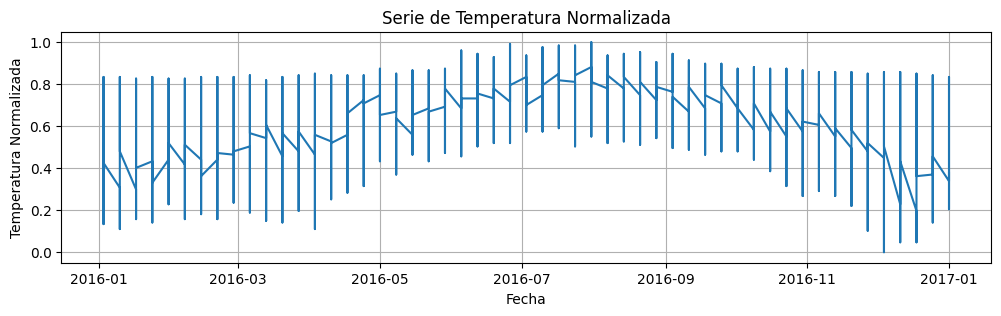

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def preprocess_data(df, date_col, target_col):

    # Convert date column to datetime
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Drop rows where date is NaT
    df.dropna(subset=[date_col], inplace=True)

    # Sort by date
    df = df.sort_values(date_col)

    # Convert target column to numeric, coercing errors
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')

    # Replace null values with the mean
    df[target_col] = df[target_col].fillna(df[target_col].mean())

    # Normalize target column
    scaler = MinMaxScaler()
    df[target_col] = scaler.fit_transform(df[[target_col]])

    return df, scaler

def plot_normalized_series(df, date_col, target_col):
    """
    Plots the normalized time series.

    Args:
        df (pd.DataFrame): The input DataFrame.
        date_col (str): The name of the date column.
        target_col (str): The name of the target column (temperature).
    """
    plt.figure(figsize=(12, 3))
    plt.plot(df[date_col], df[target_col])
    plt.title("Serie de Temperatura Normalizada")
    plt.xlabel("Fecha")
    plt.ylabel("Temperatura Normalizada")
    plt.grid(True)
    plt.show()

# Assuming the date column is named "Date.Full" and temperature column is "Data.Temperature.Avg Temp"
date_col = "Date.Full"
target_col = "Data.Temperature.Avg Temp"

# Preprocess data
df, scaler = preprocess_data(df.copy(), date_col, target_col)

# Plot normalized series
plot_normalized_series(df, date_col, target_col)

In [11]:
def create_sequences(series, window_size=30, horizon=30):
    X, y = [], []
    for i in range(len(series) - window_size - horizon):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size:i+window_size+horizon])
    return np.array(X), np.array(y)

series = df[target_col].values
window_size = 30
horizon = 30

X, y = create_sequences(series, window_size, horizon)
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Dividir en train y val (80%-20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train:", X_train.shape, "Val:", X_val.shape)



Dimensiones de X: (16683, 30)
Dimensiones de y: (16683, 30)
Train: (13346, 30) Val: (3337, 30)


In [12]:

class TempDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = {
    "train": TempDataset(X_train, y_train),
    "val": TempDataset(X_val, y_val)
}

dataloader = {
    "train": DataLoader(dataset["train"], batch_size=32, shuffle=True),
    "val": DataLoader(dataset["val"], batch_size=1000, shuffle=False)
}

print("Cantidad de muestras - Train:", len(dataset["train"]), "Val:", len(dataset["val"]))


Cantidad de muestras - Train: 13346 Val: 3337


In [13]:
def build_model(D_in=window_size, H=128, D_out=horizon):
    return nn.Sequential(
        nn.Linear(D_in, H),
        nn.ReLU(),
        nn.Linear(H, H),
        nn.ReLU(),
        nn.Linear(H, D_out)
    ).to(device)

model = build_model()
print("Modelo definido:\n", model)

Modelo definido:
 Sequential(
  (0): Linear(in_features=30, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=30, bias=True)
)


In [29]:
def fit(model, dataloader, optimizer, epochs=500, log_each=20, scheduler=None, early_stopping=150):
    criterion = nn.MSELoss()
    best_loss = float("inf")
    step = 0
    train_losses, val_losses = [], []

    for e in range(1, epochs+1):
        # Entrenamiento
        model.train()
        batch_losses = []
        for X_b, y_b in dataloader["train"]:
            y_pred = model(X_b)
            loss = criterion(y_pred, y_b)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)

        # Validación
        model.eval()
        batch_val_losses = []
        with torch.no_grad():
            for X_b, y_b in dataloader["val"]:
                y_pred = model(X_b)
                loss = criterion(y_pred, y_b)
                batch_val_losses.append(loss.item())
        val_loss = np.mean(batch_val_losses)
        val_losses.append(val_loss)

        # Guardar mejor modelo
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), "best_model.pt")
            step = 0
            print(f"Mejor modelo guardado con val_loss {best_loss:.5f} en epoch {e}")
        step += 1

        # Scheduler
        if scheduler:
            scheduler.step()

        # Early stopping
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por early stopping")
            break

        # Log
        if e % log_each == 0:
            print(f"Epoch {e}/{epochs} - Train Loss: {train_loss:.5f} - Val Loss: {val_loss:.5f}")

    model.load_state_dict(torch.load("best_model.pt"))
    return {"train_loss": train_losses, "val_loss": val_losses}


In [30]:
# SGD
model_sgd = build_model()
optimizer_sgd = torch.optim.SGD(model_sgd.parameters(), lr=0.01, momentum=0.9)
hist_sgd = fit(model_sgd, dataloader, optimizer_sgd)

Mejor modelo guardado con val_loss 0.01686 en epoch 1
Mejor modelo guardado con val_loss 0.01652 en epoch 4
Mejor modelo guardado con val_loss 0.01638 en epoch 8
Mejor modelo guardado con val_loss 0.01628 en epoch 9
Mejor modelo guardado con val_loss 0.01624 en epoch 12
Mejor modelo guardado con val_loss 0.01619 en epoch 14
Mejor modelo guardado con val_loss 0.01606 en epoch 15
Mejor modelo guardado con val_loss 0.01606 en epoch 17
Mejor modelo guardado con val_loss 0.01605 en epoch 18
Epoch 20/500 - Train Loss: 0.00896 - Val Loss: 0.01609
Mejor modelo guardado con val_loss 0.01598 en epoch 25
Mejor modelo guardado con val_loss 0.01597 en epoch 29
Mejor modelo guardado con val_loss 0.01587 en epoch 31
Mejor modelo guardado con val_loss 0.01585 en epoch 37
Epoch 40/500 - Train Loss: 0.00885 - Val Loss: 0.01594
Mejor modelo guardado con val_loss 0.01585 en epoch 48
Mejor modelo guardado con val_loss 0.01571 en epoch 50
Epoch 60/500 - Train Loss: 0.00882 - Val Loss: 0.01588
Mejor modelo g

In [31]:
# RMSProp
model_rms = build_model()
optimizer_rms = torch.optim.RMSprop(model_rms.parameters(), lr=0.001)
hist_rms = fit(model_rms, dataloader, optimizer_rms, early_stopping=150)

Mejor modelo guardado con val_loss 0.04335 en epoch 1
Mejor modelo guardado con val_loss 0.01853 en epoch 2
Mejor modelo guardado con val_loss 0.01628 en epoch 5
Mejor modelo guardado con val_loss 0.01542 en epoch 8
Mejor modelo guardado con val_loss 0.01525 en epoch 15
Mejor modelo guardado con val_loss 0.01450 en epoch 18
Epoch 20/500 - Train Loss: 0.00763 - Val Loss: 0.01464
Mejor modelo guardado con val_loss 0.01378 en epoch 22
Mejor modelo guardado con val_loss 0.01344 en epoch 33
Mejor modelo guardado con val_loss 0.01319 en epoch 36
Mejor modelo guardado con val_loss 0.01275 en epoch 38
Epoch 40/500 - Train Loss: 0.00661 - Val Loss: 0.01283
Mejor modelo guardado con val_loss 0.01237 en epoch 43
Mejor modelo guardado con val_loss 0.01209 en epoch 50
Epoch 60/500 - Train Loss: 0.00610 - Val Loss: 0.01367
Mejor modelo guardado con val_loss 0.01197 en epoch 78
Epoch 80/500 - Train Loss: 0.00580 - Val Loss: 0.01605
Mejor modelo guardado con val_loss 0.01161 en epoch 100
Epoch 100/500

In [32]:
# Adam
model_adam = build_model()
optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)
hist_adam = fit(model_adam, dataloader, optimizer_adam, early_stopping=150)

Mejor modelo guardado con val_loss 0.01599 en epoch 1
Mejor modelo guardado con val_loss 0.01579 en epoch 2
Mejor modelo guardado con val_loss 0.01548 en epoch 4
Mejor modelo guardado con val_loss 0.01526 en epoch 5
Mejor modelo guardado con val_loss 0.01522 en epoch 6
Mejor modelo guardado con val_loss 0.01517 en epoch 8
Mejor modelo guardado con val_loss 0.01514 en epoch 9
Mejor modelo guardado con val_loss 0.01488 en epoch 11
Mejor modelo guardado con val_loss 0.01464 en epoch 14
Mejor modelo guardado con val_loss 0.01460 en epoch 16
Mejor modelo guardado con val_loss 0.01413 en epoch 18
Mejor modelo guardado con val_loss 0.01398 en epoch 20
Epoch 20/500 - Train Loss: 0.00800 - Val Loss: 0.01398
Mejor modelo guardado con val_loss 0.01387 en epoch 23
Mejor modelo guardado con val_loss 0.01368 en epoch 26
Mejor modelo guardado con val_loss 0.01361 en epoch 29
Mejor modelo guardado con val_loss 0.01328 en epoch 30
Mejor modelo guardado con val_loss 0.01306 en epoch 31
Mejor modelo guar

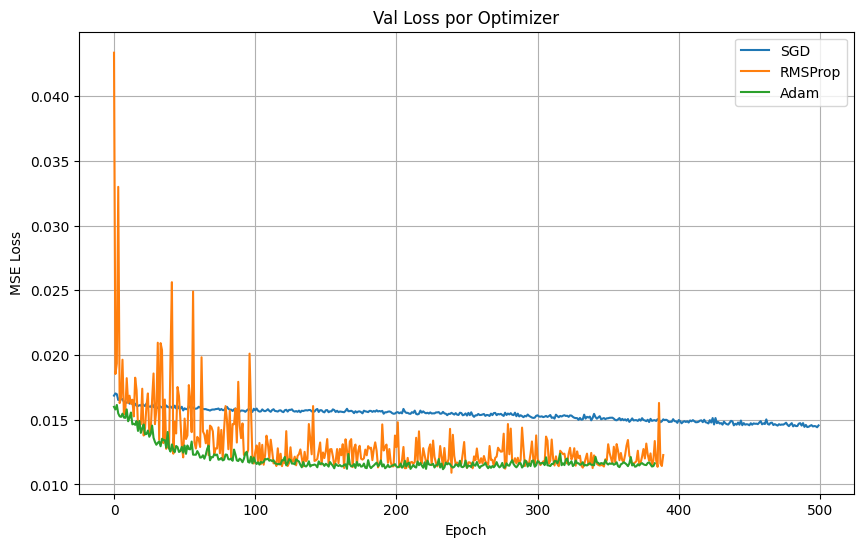

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(hist_sgd["val_loss"], label="SGD")
plt.plot(hist_rms["val_loss"], label="RMSProp")
plt.plot(hist_adam["val_loss"], label="Adam")

plt.title("Val Loss por Optimizer")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

Evaluation Metrics:
RMSE: 0.10, MAE: 0.08, R²: 0.44

First Sample Predictions vs Actual:
Actual Values (First 30 days): [0.67716535 0.61417323 0.58267717 0.63779528 0.62204724 0.72440945
 0.68503937 0.78740157 0.79527559 0.60629921 0.5984252  0.62204724
 0.5984252  0.57480315 0.74015748 0.7480315  0.69291339 0.75590551
 0.70866142 0.87401575 0.7007874  0.68503937 0.69291339 0.74015748
 0.72440945 0.73228346 0.75590551 0.74015748 0.69291339 0.78740157]
Predicted Values (First 30 days): [0.707488   0.69665897 0.68518203 0.64279693 0.64974964 0.6746099
 0.6501991  0.67368585 0.6600486  0.62969476 0.6233143  0.67857134
 0.68816614 0.70238024 0.73408484 0.73234344 0.73756945 0.73383695
 0.7249179  0.67715263 0.6800622  0.6481004  0.6730553  0.72326475
 0.75058043 0.7632078  0.77986956 0.751986   0.73506576 0.74097514]


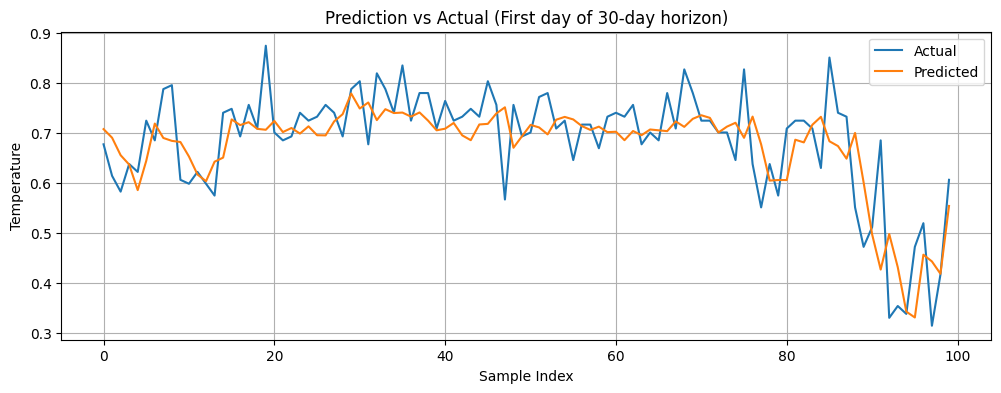

In [34]:
# Evaluate the model and make predictions
model = model_adam  # Assuming model_adam is the best performing model
model.eval()

with torch.no_grad():
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_pred_val = model(X_val_tensor).cpu().numpy()
    y_true_val = y_val

# Inverse transform the scaled data
y_pred_rescaled = scaler.inverse_transform(y_pred_val)
y_true_rescaled = scaler.inverse_transform(y_true_val)

# Calculate and print evaluation metrics
rmse = np.sqrt(mean_squared_error(y_true_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_true_rescaled, y_pred_rescaled)
r2 = r2_score(y_true_rescaled, y_pred_rescaled)

print(f"Evaluation Metrics:\nRMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}")

# Display the first sample's predicted and true values
sample_index = 0
print("\nFirst Sample Predictions vs Actual:")
print("Actual Values (First 30 days):", y_true_rescaled[sample_index, :])
print("Predicted Values (First 30 days):", y_pred_rescaled[sample_index, :])

# Plot the first day of the horizon for a subset of samples
plt.figure(figsize=(12, 4))
plt.plot(y_true_rescaled[:100, 0], label="Actual")
plt.plot(y_pred_rescaled[:100, 0], label="Predicted")
plt.title("Prediction vs Actual (First day of 30-day horizon)")
plt.xlabel("Sample Index")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

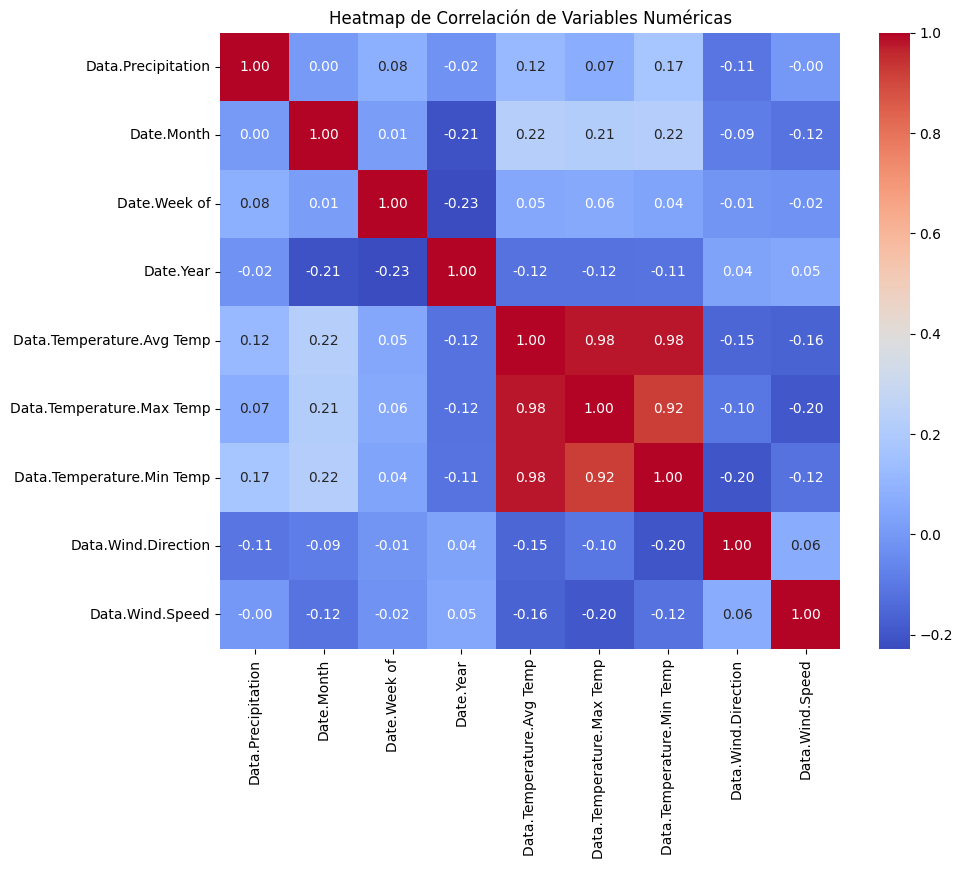

In [23]:
import seaborn as sns

# Select only numerical columns for the heatmap
df_numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de Correlación de Variables Numéricas')
plt.show()